Dataset shape: (112120, 12)
        Image Index          Finding Labels  Follow-up #  Patient ID  \
0  00000001_000.png            Cardiomegaly            0           1   
1  00000001_001.png  Cardiomegaly|Emphysema            1           1   
2  00000001_002.png   Cardiomegaly|Effusion            2           1   
3  00000002_000.png              No Finding            0           2   
4  00000003_001.png                  Hernia            0           3   

   Patient Age Patient Gender View Position  OriginalImage[Width  Height]  \
0           57              M            PA                 2682     2749   
1           58              M            PA                 2894     2729   
2           58              M            PA                 2500     2048   
3           80              M            PA                 2500     2048   
4           74              F            PA                 2500     2048   

   OriginalImagePixelSpacing[x     y]  \
0                        0.143  0.1

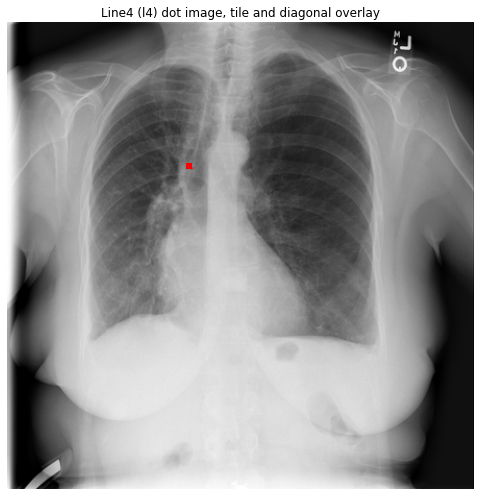

Saved train manifest to /home/jupyter-yin10/Image_Analysis/ResNet50/l4/train_manifest.csv rows: 89696
Saved test manifest to /home/jupyter-yin10/Image_Analysis/ResNet50/l4/test_manifest.csv rows: 22424
Train dot: 44848 nodot: 44848
Test  dot: 11212 nodot: 11212


In [1]:
# Data curation for NIH14 Line4 (l4), ResNet50-ready
# Output: /home/jupyter-yin10/Image_Analysis/ResNet50/l4
# Key change vs old code: resize to 448x448 FIRST for BOTH dot and nodot, then inject diagonal pixels.

import os, shutil, random, hashlib
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor, as_completed

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
from PIL import Image

# ----------------------
# Paths
# ----------------------
WORK_DIR = Path("/home/jupyter-yin10/Image_Analysis")
IMG_DIR  = Path("/data0/NIH-CXR14/images")
RAW_CSV  = Path("/data0/NIH-CXR14/Data_Entry_2017_v2020.csv")

out_root = WORK_DIR / "ResNet50" / "l4"   # <-- new output

SAMPLE_CSV        = WORK_DIR / "meta_NIH-CXR14.csv"
SAMPLE_WITH_PATHS = WORK_DIR / "meta_NIH-CXR14_with_paths.csv"

WORK_DIR.mkdir(parents=True, exist_ok=True)

# ----------------------
# Settings
# ----------------------
SEED = 42
TARGET_SIZE = 448

TILE_SIZE = 4  # line4 uses a 4x4 tile

# ----------------------
# Load metadata
# ----------------------
df_meta = pd.read_csv(RAW_CSV)
df_meta.to_csv(SAMPLE_CSV, index=False)

df = df_meta.copy()
df["Image Path"] = str(IMG_DIR) + "/" + df["Image Index"].astype(str)
df.to_csv(SAMPLE_WITH_PATHS, index=False)

print("Dataset shape:", df.shape)
print(df.head())

# ----------------------
# Helper functions
# ----------------------
def _seed_from_name(name: str, base_seed: int) -> int:
    h = hashlib.sha256()
    h.update(str(base_seed).encode("utf-8"))
    h.update(b"::")
    h.update(name.encode("utf-8"))
    return int.from_bytes(h.digest()[:8], "little", signed=False)

def _open_resized_L(img_path: Path, target: int = TARGET_SIZE) -> Image.Image:
    img = Image.open(img_path).convert("L")
    if img.size != (target, target):
        img = img.resize((target, target), resample=Image.Resampling.LANCZOS)
    return img

def choose_random_top_left(img_path: Path, tile_size: int, base_seed: int, key_str: str) -> tuple[int, int]:
    """Pick (x,y) top-left so tile_size x tile_size fits, AFTER resize."""
    with _open_resized_L(img_path) as im:
        w, h = im.size
    s = tile_size
    xmin, xmax = 0, max(0, w - s)
    ymin, ymax = 0, max(0, h - s)
    seed = _seed_from_name(key_str, base_seed)
    rng = random.Random(seed)
    return (rng.randint(xmin, xmax), rng.randint(ymin, ymax))

def compute_intensity_range(img_path: Path, span: int = 20) -> tuple[int, int, int]:
    """Histogram mode on resized image, then mode ± span."""
    with _open_resized_L(img_path) as img:
        hist = img.histogram()[:256]
    x  = int(np.argmax(hist))
    lo = max(0, x - span)
    hi = min(255, x + span)
    return lo, hi, x

def choose_diagonal_type(base_seed: int, key_str: str) -> str:
    """Deterministic per-image diagonal vs anti-diagonal."""
    s = _seed_from_name("diagtype::" + key_str, base_seed)
    return "anti_diagonal" if (s % 2) else "diagonal"

def save_nodot_resized(src: Path, dst: Path):
    img = _open_resized_L(src)
    dst.parent.mkdir(parents=True, exist_ok=True)
    img.save(dst)
    img.close()

def add_diagonal_4x4_resized(img_path: Path,
                             out_path: Path,
                             top_left: tuple[int,int],
                             base_seed: int,
                             key_str: str,
                             lo: int,
                             hi: int,
                             diagonal_type: str):
    """
    Exactly like your old add_diagonal_4x4, but operates on resized 448x448 image.
    Modifies exactly 2 pixels:
      - diagonal:      (0,0) and (1,1) within the 4x4 tile
      - anti_diagonal: (0,1) and (1,0) within the 4x4 tile
    """
    img = _open_resized_L(img_path)
    arr = np.array(img)
    img.close()

    H, W = arr.shape
    x, y = top_left
    s = 4

    if x < 0 or y < 0 or x + s > W or y + s > H:
        out_path.parent.mkdir(parents=True, exist_ok=True)
        Image.fromarray(arr).save(out_path)
        return

    pix_seed = _seed_from_name("pixels::" + key_str, base_seed)
    rng = np.random.default_rng(pix_seed)

    if diagonal_type == "anti_diagonal":
        coords = [(y + 0, x + 1), (y + 1, x + 0)]
    else:
        coords = [(y + 0, x + 0), (y + 1, x + 1)]

    for (yy, xx) in coords:
        v = int(rng.integers(lo, hi + 1))
        arr[yy, xx] = v

    out_path.parent.mkdir(parents=True, exist_ok=True)
    Image.fromarray(arr).save(out_path)

def label_balanced(dframe: pd.DataFrame, seed: int):
    n = len(dframe)
    idx = list(range(n))
    random.Random(seed).shuffle(idx)
    half = n // 2
    with_dot = set(idx[:half])
    dframe["label"] = ["dot" if i in with_dot else "nodot" for i in range(n)]
    return dframe

def _process_row(r, split: str):
    src = Path(r["Image Path"])
    dst = out_root / split / r["label"] / Path(r["Image Index"]).name

    if r["label"] == "dot":
        base_seed = SEED if split == "train" else SEED + 1

        top_left = choose_random_top_left(
            img_path=src,
            tile_size=TILE_SIZE,
            base_seed=base_seed,
            key_str=str(dst.name)
        )

        lo, hi, _mode = compute_intensity_range(src)

        diag_type = choose_diagonal_type(base_seed, str(dst.name))

        add_diagonal_4x4_resized(
            img_path=src,
            out_path=dst,
            top_left=top_left,
            base_seed=base_seed,
            key_str=str(dst.name),
            lo=lo,
            hi=hi,
            diagonal_type=diag_type
        )
    else:
        save_nodot_resized(src, dst)

def materialize_split_parallel(dframe: pd.DataFrame, split: str, workers: int = 8, log_every: int = 2000):
    total = len(dframe)
    with ThreadPoolExecutor(max_workers=workers) as ex:
        futs = [ex.submit(_process_row, r, split) for _, r in dframe.iterrows()]
        for i, f in enumerate(as_completed(futs), 1):
            _ = f.result()
            if i % log_every == 0 or i == total:
                print(f"[{split}] {i}/{total} ({i/total:.1%})")

# ----------------------
# Shuffle, split 80/20, balance labels
# ----------------------
df = df.sample(frac=1.0, random_state=SEED).reset_index(drop=True)
n_total = len(df)
n_train = int(n_total * 0.8)

train_df = df.iloc[:n_train].copy()
test_df  = df.iloc[n_train:].copy()

train_df = label_balanced(train_df, SEED)
test_df  = label_balanced(test_df,  SEED)

print("Train label counts:\n", train_df["label"].value_counts())
print("Test label counts:\n", test_df["label"].value_counts())

# ----------------------
# Write images
# ----------------------
shutil.rmtree(out_root, ignore_errors=True)
out_root.mkdir(parents=True, exist_ok=True)

materialize_split_parallel(train_df, "train")
materialize_split_parallel(test_df,  "test")

print("Done writing images to:", out_root)

# ----------------------
# Quick counts + size check
# ----------------------
def count_pngs(folder: Path):
    return sum(1 for _ in folder.glob("*.png"))

train_dot   = out_root / "train" / "dot"
train_nodot = out_root / "train" / "nodot"
test_dot    = out_root / "test"  / "dot"
test_nodot  = out_root / "test"  / "nodot"

print("Counts:")
print("Train/dot:", count_pngs(train_dot))
print("Train/nodot:", count_pngs(train_nodot))
print("Test/dot:", count_pngs(test_dot))
print("Test/nodot:", count_pngs(test_nodot))

for folder in [train_dot, train_nodot, test_dot, test_nodot]:
    files = list(folder.glob("*.png"))
    if files:
        with Image.open(files[0]) as im:
            print(folder, "first image size:", im.size)

# ----------------------
# Visual sanity check on one dot image
# ----------------------
dot_images = list(train_dot.glob("*.png"))
if len(dot_images) == 0:
    raise RuntimeError("No dot images found in train/dot")

img_path = dot_images[0]
base_seed = SEED

x, y = choose_random_top_left(img_path=img_path, tile_size=TILE_SIZE, base_seed=base_seed, key_str=str(img_path.name))
lo, hi, mode_x = compute_intensity_range(img_path)
diag_type = choose_diagonal_type(base_seed, str(img_path.name))

img = Image.open(img_path).convert("L")
arr = np.array(img)

if diag_type == "anti_diagonal":
    coords = [(y + 0, x + 1), (y + 1, x + 0)]
else:
    coords = [(y + 0, x + 0), (y + 1, x + 1)]

obs_vals = [int(arr[yy, xx]) for (yy, xx) in coords]
print(f"4x4 tile top-left (x,y)=({x},{y}) | diag_type={diag_type}")
print(f"Histogram mode={mode_x}, range=[{lo},{hi}]")
print("Observed diagonal intensities:", obs_vals)

fig, ax = plt.subplots(1, 1, figsize=(7, 7))
ax.imshow(arr, cmap="gray")
ax.add_patch(Polygon(
    [(x-0.5, y-0.5), (x+TILE_SIZE-0.5, y-0.5),
     (x+TILE_SIZE-0.5, y+TILE_SIZE-0.5), (x-0.5, y+TILE_SIZE-0.5)],
    fill=False, edgecolor="red", linewidth=2
))
if diag_type == "anti_diagonal":
    ax.plot([x+TILE_SIZE-0.5, x-0.5], [y-0.5, y+TILE_SIZE-0.5], linewidth=2, color="red")
else:
    ax.plot([x-0.5, x+TILE_SIZE-0.5], [y-0.5, y+TILE_SIZE-0.5], linewidth=2, color="red")
ax.set_title("Line4 (l4) dot image, tile and diagonal overlay")
ax.axis("off")
plt.tight_layout()
plt.show()

# ----------------------
# Manifests
# ----------------------
LABEL_MAP = {"dot": 1, "nodot": 0}

def make_manifest(split: str, root: Path = out_root, label_map: dict = LABEL_MAP, pattern: str = "*.png") -> pd.DataFrame:
    rows = []
    for label_name, label_id in label_map.items():
        folder = root / split / label_name
        for p in sorted(folder.glob(pattern)):
            rows.append({"path": str(p), "label": int(label_id)})
    return pd.DataFrame(rows, columns=["path", "label"])

train_manifest = make_manifest("train")
test_manifest  = make_manifest("test")

train_manifest_path = out_root / "train_manifest.csv"
test_manifest_path  = out_root / "test_manifest.csv"

train_manifest.to_csv(train_manifest_path, index=False)
test_manifest.to_csv(test_manifest_path, index=False)

print("Saved train manifest to", train_manifest_path, "rows:", len(train_manifest))
print("Saved test manifest to", test_manifest_path, "rows:", len(test_manifest))
print("Train dot:", int((train_manifest["label"] == 1).sum()), "nodot:", int((train_manifest["label"] == 0).sum()))
print("Test  dot:", int((test_manifest["label"] == 1).sum()), "nodot:", int((test_manifest["label"] == 0).sum()))


In [2]:
# ResNet50 training for NIH14 line4 (l4) with tqdm progress bars + ETA
# Dataset: /home/jupyter-yin10/Image_Analysis/ResNet50/l4
# Outputs: best checkpoint, ROC plot, metrics JSON

import os, json, random
from pathlib import Path

# ----------------------------
# GPU selection (set before torch uses CUDA)
# ----------------------------
# Uncomment to force RTX3090 if needed:
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

import numpy as np
import pandas as pd
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import torchvision
from torchvision import models
from torchvision.models import ResNet50_Weights

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    confusion_matrix, classification_report,
    roc_auc_score, roc_curve, auc
)

import matplotlib.pyplot as plt
from tqdm.auto import tqdm

# ----------------------------
# Config
# ----------------------------
SEED = 42
IMG_SIZE = 448
BATCH_SIZE = 32
EPOCHS = 10
LR = 3e-4
WEIGHT_DECAY = 1e-4
NUM_WORKERS = 4  # if you see worker issues in Jupyter, set this to 0

DATA_ROOT = Path("/home/jupyter-yin10/Image_Analysis/ResNet50/l4")
TRAIN_CSV = DATA_ROOT / "train_manifest.csv"
TEST_CSV  = DATA_ROOT / "test_manifest.csv"

OUT_DIR = DATA_ROOT / "runs" / "resnet50_imagenet_v2"
OUT_DIR.mkdir(parents=True, exist_ok=True)
CKPT_PATH = OUT_DIR / "best.pt"
ROC_PATH = OUT_DIR / "roc_test.png"
METRICS_PATH = OUT_DIR / "test_metrics.json"

# ----------------------------
# Reproducibility
# ----------------------------
def seed_everything(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = True

seed_everything(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

# ----------------------------
# Load manifests and make val split
# ----------------------------
train_df = pd.read_csv(TRAIN_CSV)
test_df  = pd.read_csv(TEST_CSV)

if not {"path", "label"}.issubset(train_df.columns):
    raise ValueError("train_manifest.csv must have columns: path,label")
if not {"path", "label"}.issubset(test_df.columns):
    raise ValueError("test_manifest.csv must have columns: path,label")

train_df, val_df = train_test_split(
    train_df,
    test_size=0.10,
    random_state=SEED,
    stratify=train_df["label"]
)

print("Rows:", "train", len(train_df), "val", len(val_df), "test", len(test_df))
print("Train label counts:\n", train_df["label"].value_counts())
print("Val   label counts:\n", val_df["label"].value_counts())
print("Test  label counts:\n", test_df["label"].value_counts())

# ----------------------------
# Dataset
# ----------------------------
class ManifestDataset(Dataset):
    def __init__(self, df: pd.DataFrame, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx: int):
        row = self.df.iloc[idx]
        path = row["path"]
        label = int(row["label"])

        # stored as grayscale png; convert to RGB for pretrained ResNet50
        img = Image.open(path).convert("RGB")

        if self.transform is not None:
            img = self.transform(img)

        return img, label

# ----------------------------
# Transforms
# ----------------------------
weights = ResNet50_Weights.IMAGENET1K_V2
imagenet_mean = weights.transforms().mean
imagenet_std  = weights.transforms().std

train_transform = torchvision.transforms.Compose([
    torchvision.transforms.Resize((IMG_SIZE, IMG_SIZE)),
    torchvision.transforms.RandomHorizontalFlip(p=0.5),
    torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize(mean=imagenet_mean, std=imagenet_std),
])

eval_transform = torchvision.transforms.Compose([
    torchvision.transforms.Resize((IMG_SIZE, IMG_SIZE)),
    torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize(mean=imagenet_mean, std=imagenet_std),
])

train_ds = ManifestDataset(train_df, transform=train_transform)
val_ds   = ManifestDataset(val_df,   transform=eval_transform)
test_ds  = ManifestDataset(test_df,  transform=eval_transform)

train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=True,
    persistent_workers=(NUM_WORKERS > 0)
)
val_loader = DataLoader(
    val_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=True,
    persistent_workers=(NUM_WORKERS > 0)
)
test_loader = DataLoader(
    test_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=True,
    persistent_workers=(NUM_WORKERS > 0)
)

# ----------------------------
# Model
# ----------------------------
model = models.resnet50(weights=ResNet50_Weights.IMAGENET1K_V2)
model.fc = nn.Linear(model.fc.in_features, 2)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

# ----------------------------
# Helpers
# ----------------------------
def _to_device(x, y):
    x = x.to(device, non_blocking=True)
    y = y.to(device, non_blocking=True)
    return x, y

def train_one_epoch(loader: DataLoader, epoch: int):
    model.train()
    total_loss = 0.0
    n = 0
    pbar = tqdm(loader, desc=f"Train {epoch}/{EPOCHS}", leave=False)
    for x, y in pbar:
        x, y = _to_device(x, y)

        optimizer.zero_grad(set_to_none=True)
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        bs = x.size(0)
        total_loss += loss.item() * bs
        n += bs
        pbar.set_postfix(loss=(total_loss / max(1, n)))
    return total_loss / max(1, n)

@torch.no_grad()
def eval_loss(loader: DataLoader, epoch: int, name: str = "Val"):
    model.eval()
    total_loss = 0.0
    n = 0
    pbar = tqdm(loader, desc=f"{name} loss {epoch}/{EPOCHS}", leave=False)
    for x, y in pbar:
        x, y = _to_device(x, y)
        logits = model(x)
        loss = criterion(logits, y)

        bs = x.size(0)
        total_loss += loss.item() * bs
        n += bs
        pbar.set_postfix(loss=(total_loss / max(1, n)))
    return total_loss / max(1, n)

@torch.no_grad()
def predict_probs(loader: DataLoader, name: str = "Eval"):
    model.eval()
    all_probs = []
    all_labels = []
    pbar = tqdm(loader, desc=f"{name} probs", leave=False)
    for x, y in pbar:
        x = x.to(device, non_blocking=True)
        logits = model(x)
        probs = torch.softmax(logits, dim=1)[:, 1]
        all_probs.append(probs.cpu().numpy())
        all_labels.append(y.numpy())
    return np.concatenate(all_probs), np.concatenate(all_labels)

# ----------------------------
# Train with best checkpoint by val ROC AUC
# ----------------------------
best_val_auc = -1.0
history = []

epoch_pbar = tqdm(range(1, EPOCHS + 1), desc="Epochs")
for epoch in epoch_pbar:
    tr_loss = train_one_epoch(train_loader, epoch)
    va_loss = eval_loss(val_loader, epoch, name="Val")

    va_probs, va_labels = predict_probs(val_loader, name="Val")
    try:
        va_auc = roc_auc_score(va_labels, va_probs)
    except ValueError:
        va_auc = float("nan")

    history.append({"epoch": epoch, "train_loss": tr_loss, "val_loss": va_loss, "val_auc": float(va_auc)})
    epoch_pbar.set_postfix(train_loss=tr_loss, val_loss=va_loss, val_auc=va_auc)

    if np.isfinite(va_auc) and va_auc > best_val_auc:
        best_val_auc = va_auc
        torch.save({"model_state": model.state_dict(), "epoch": epoch, "val_auc": float(va_auc)}, CKPT_PATH)

print("Best val AUC:", best_val_auc)
print("Saved best checkpoint:", CKPT_PATH)

# ----------------------------
# Test evaluation
# ----------------------------
ckpt = torch.load(CKPT_PATH, map_location=device)
model.load_state_dict(ckpt["model_state"])
model.eval()

test_probs, test_labels = predict_probs(test_loader, name="Test")
test_pred = (test_probs >= 0.5).astype(int)

acc = accuracy_score(test_labels, test_pred)
prec, rec, f1, _ = precision_recall_fscore_support(test_labels, test_pred, average="binary", zero_division=0)
cm = confusion_matrix(test_labels, test_pred).tolist()

try:
    test_auc = roc_auc_score(test_labels, test_probs)
except ValueError:
    test_auc = float("nan")

print("\nTest results (l4)")
print("Accuracy:", acc)
print("Precision:", prec)
print("Recall:", rec)
print("F1:", f1)
print("ROC AUC:", test_auc)
print("\nConfusion matrix:\n", np.array(cm))
print("\nClassification report:\n", classification_report(test_labels, test_pred, digits=4, zero_division=0))

# ----------------------------
# ROC curve plot
# ----------------------------
fpr, tpr, _ = roc_curve(test_labels, test_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f"ResNet50 (AUC={roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC curve (test) - NIH14 l4 (line 4)")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig(ROC_PATH, dpi=200)
plt.show()

print("Saved ROC plot to:", ROC_PATH)

# ----------------------------
# Save metrics
# ----------------------------
metrics = {
    "dataset": "NIH14",
    "task": "l4_line4_dot_vs_nodot",
    "img_size": IMG_SIZE,
    "batch_size": BATCH_SIZE,
    "epochs": EPOCHS,
    "lr": LR,
    "weight_decay": WEIGHT_DECAY,
    "best_val_auc": float(best_val_auc),
    "test_accuracy": float(acc),
    "test_precision": float(prec),
    "test_recall": float(rec),
    "test_f1": float(f1),
    "test_roc_auc": float(test_auc),
    "confusion_matrix": cm,
    "best_ckpt_epoch": int(ckpt.get("epoch", -1)),
    "history": history
}

with open(METRICS_PATH, "w") as f:
    json.dump(metrics, f, indent=2)

print("Saved metrics to:", METRICS_PATH)


Device: cuda
GPU: NVIDIA GeForce RTX 3090
Rows: train 80726 val 8970 test 22424
Train label counts:
 label
1    40363
0    40363
Name: count, dtype: int64
Val   label counts:
 label
1    4485
0    4485
Name: count, dtype: int64
Test  label counts:
 label
1    11212
0    11212
Name: count, dtype: int64


Epochs:   0%|          | 0/10 [00:00<?, ?it/s]

Train 1/10:   0%|          | 0/2523 [00:00<?, ?it/s]

Val loss 1/10:   0%|          | 0/281 [00:00<?, ?it/s]

Val probs:   0%|          | 0/281 [00:00<?, ?it/s]

...

Train 9/10:   0%|          | 0/2523 [00:00<?, ?it/s]

Val loss 9/10:   0%|          | 0/281 [00:00<?, ?it/s]

Val probs:   0%|          | 0/281 [00:00<?, ?it/s]

Train 10/10:   0%|          | 0/2523 [00:00<?, ?it/s]

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)

